# CreditWise: Loan Approval Prediction System

In [ ]:
Built an end-to-end supervised machine learning pipeline to predict loan approval using binary classification techniques. The project includes exploratory data analysis (EDA), feature engineering, and data preprocessing (handling missing values, feature scaling, and one-hot encoding).

Implemented and compared multiple classification models including Naive Bayes, Logistic Regression, and K-Nearest Neighbors (KNN). Model performance was evaluated using precision, recall, and F1-score, with special emphasis on handling class imbalance, where accuracy alone is insufficient.

Naive Bayes achieved the best overall performance on the imbalanced dataset, while Logistic Regression showed competitive results when balancing precision and recall. KNN performed poorly due to sensitivity to class imbalance and high dimensionality caused by one-hot encoding.

In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
loan_df=pd.read_csv("loan_approval_data.csv")

In [3]:
loan_df

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996.0,NaN,9092.0,Salaried,58.0,Married,0.0,557.0,0.0,0.59,5370.0,43563.0,8311.0,72.0,Personal,NaN,Not Graduate,Male,Unemployed,No
996,997.0,3279.0,6356.0,Self-employed,58.0,Married,1.0,646.0,3.0,0.19,NaN,18361.0,22563.0,12.0,Business,Urban,Graduate,Female,Government,No
997,998.0,15192.0,8433.0,Contract,48.0,Single,1.0,666.0,1.0,0.40,8581.0,41335.0,16203.0,24.0,Home,Rural,Graduate,Male,MNC,No
998,999.0,9083.0,7380.0,Unemployed,50.0,Single,1.0,748.0,3.0,0.31,13491.0,8933.0,10290.0,36.0,Personal,Urban,Graduate,Male,Private,Yes


In [4]:
loan_df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [5]:
loan_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

In [6]:
loan_df.isnull().sum()

Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

In [7]:
loan_df.describe

<bound method NDFrame.describe of      Applicant_ID  Applicant_Income  Coapplicant_Income Employment_Status  \
0             1.0           17795.0              1387.0          Salaried   
1             2.0            2860.0              2679.0          Salaried   
2             3.0            7390.0              2106.0          Salaried   
3             4.0           13964.0              8173.0          Salaried   
4             5.0           13284.0              4223.0     Self-employed   
..            ...               ...                 ...               ...   
995         996.0               NaN              9092.0          Salaried   
996         997.0            3279.0              6356.0     Self-employed   
997         998.0           15192.0              8433.0          Contract   
998         999.0            9083.0              7380.0        Unemployed   
999        1000.0           13093.0              2385.0          Salaried   

      Age Marital_Status  Dependents  Cre

In [8]:
# data clearing 
##handaling missing value

In [9]:
categorical_cols=loan_df.select_dtypes(include=["object"]).columns
numerical_cols=loan_df.select_dtypes(include=["float64"]).columns# int64,numberalso use 



In [10]:
categorical_cols

Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
       'Education_Level', 'Gender', 'Employer_Category', 'Loan_Approved'],
      dtype='object')

In [11]:
categorical_cols.size

8

In [12]:
numerical_cols

Index(['Applicant_ID', 'Applicant_Income', 'Coapplicant_Income', 'Age',
       'Dependents', 'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term'],
      dtype='object')

In [13]:
numerical_cols.size

12

In [14]:
categorical_cols.size+numerical_cols.size

20

In [15]:
from sklearn.impute import SimpleImputer
#Define categorical columns
numerical_cols=loan_df.select_dtypes(include=["float64"]).columns# int64,numberalso use 
#Create the imputer
numerical_imp=SimpleImputer(strategy="mean")
#Apply imputation
loan_df[numerical_cols]=numerical_imp.fit_transform(loan_df[numerical_cols])

In [16]:
loan_df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [17]:
from sklearn.impute import SimpleImputer
#Define categorical columns
categorical_cols=loan_df.select_dtypes(include=["object"]).columns
#Create the imputer
categorical_imp=SimpleImputer(strategy="most_frequent")
#Apply imputation
loan_df[categorical_cols]=categorical_imp.fit_transform(loan_df[categorical_cols])

In [18]:
loan_df.head()
loan_df.isnull().sum()

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

# EDA 

Text(0.5, 1.0, 'is loan approved or not?')

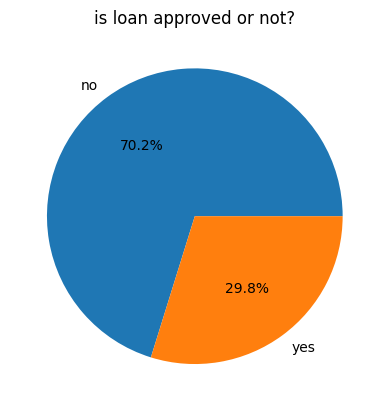

In [19]:
## how balanced our classes are?

calsses_count=loan_df["Loan_Approved"].value_counts()
plt.pie(calsses_count,labels=["no","yes"],autopct="%1.1f%%")
plt.title("is loan approved or not?")

In [20]:
## analyze categories with gender value 

[Text(0, 0, '621'), Text(0, 0, '379')]

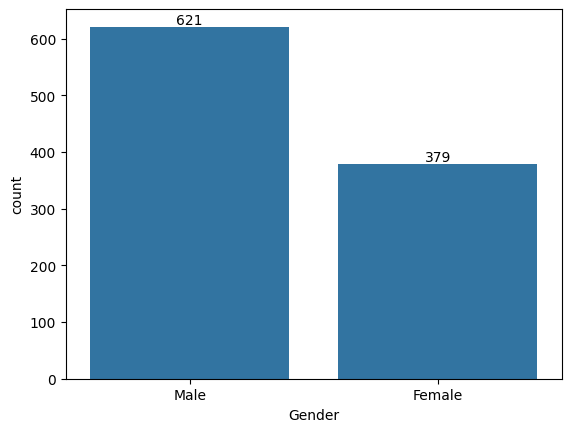

In [21]:
gender_count=loan_df["Gender"].value_counts()
ax=sns.barplot(gender_count)
ax.bar_label(ax.containers[0])

In [22]:
## analyze categories with Education_Level value 


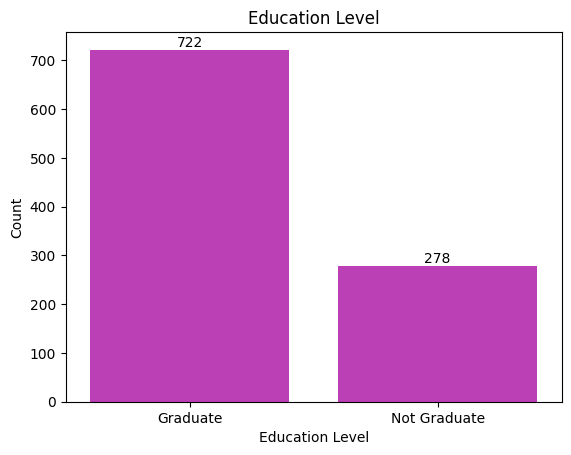

In [23]:
Education_Level=loan_df["Education_Level"].value_counts()
ax=sns.barplot(Education_Level,color="#cf2bc9")
ax.set_title("Education Level")
ax.set_xlabel("Education Level")
ax.set_ylabel("Count")
ax.bar_label(ax.containers[0])
plt.show()

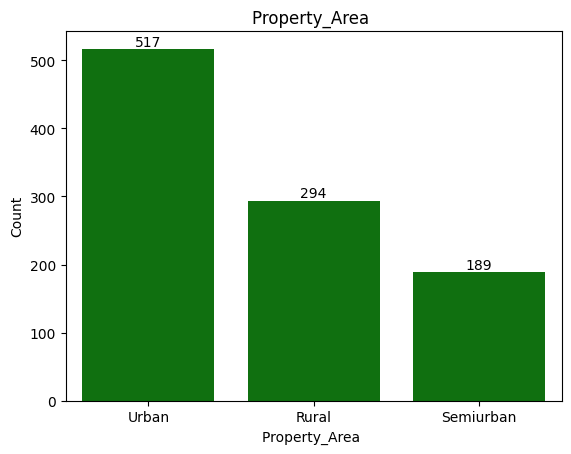

In [24]:
## analyze categories with Property_Area     
Property_Area =loan_df["Property_Area"].value_counts()
ax=sns.barplot(Property_Area,color="green")
ax.set_title("Property_Area ")
ax.set_xlabel("Property_Area ")
ax.set_ylabel("Count")
ax.bar_label(ax.containers[0])
plt.show()

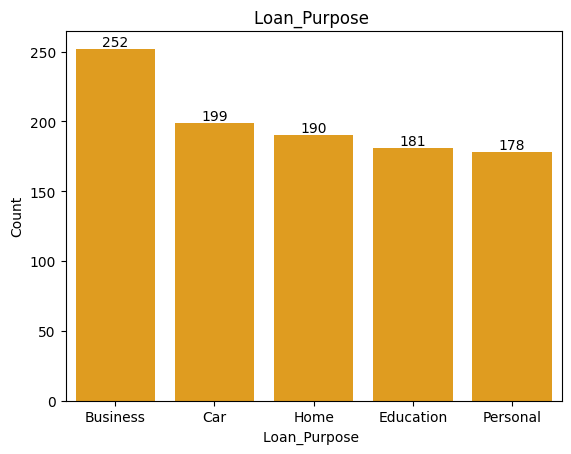

In [25]:
## analyze categories with Loan_Purpose
Loan_Purpose =loan_df["Loan_Purpose"].value_counts()
ax=sns.barplot(Loan_Purpose, color="orange"  )
ax.set_title("Loan_Purpose ")
ax.set_xlabel("Loan_Purpose ")
ax.set_ylabel("Count")
ax.bar_label(ax.containers[0])
plt.show()

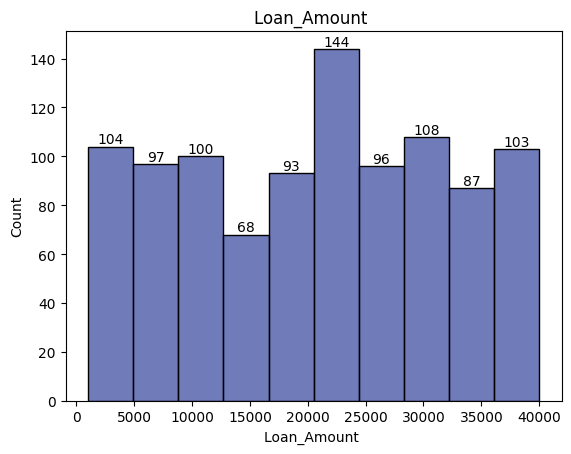

In [26]:
## analyze categories with Loan_Amount 
Loan_Amount =loan_df["Loan_Amount"].value_counts()
ax = sns.histplot(
    loan_df["Loan_Amount"],
    bins=10,
    color="#404fa3"

  )
ax.set_title("Loan_Amount ")
ax.set_xlabel("Loan_Amount ")
ax.set_ylabel("Count")
ax.bar_label(ax.containers[0])
plt.show()

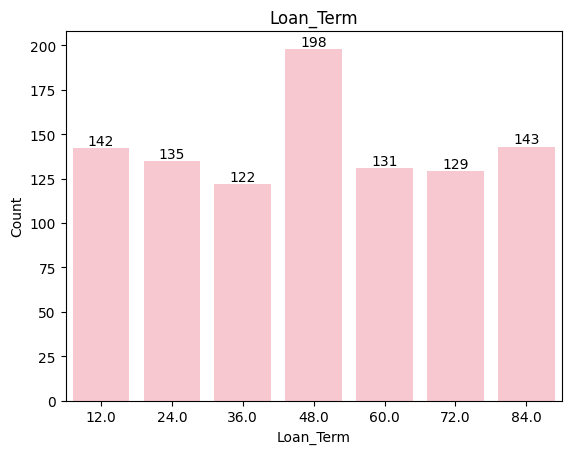

In [27]:
## analyze categories with Loan_Term  
Loan_Term   =loan_df["Loan_Term"].value_counts()
ax=sns.barplot(Loan_Term,color="pink"  )
ax.set_title("Loan_Term")
ax.set_xlabel("Loan_Term")
ax.set_ylabel("Count")
ax.bar_label(ax.containers[0])
plt.show()

In [28]:
# analyze income

<Axes: xlabel='Applicant_Income', ylabel='Count'>

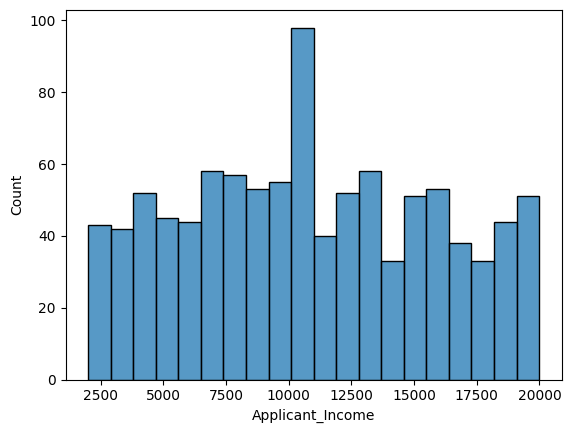

In [29]:
sns.histplot(
    data=loan_df,
    x="Applicant_Income",
    bins=20
            )

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

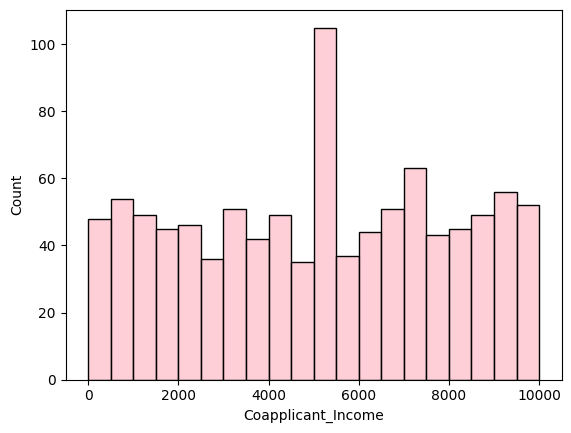

In [30]:
sns.histplot(
    data=loan_df,
    x="Coapplicant_Income",
    bins=20,
    color="pink"
            )

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

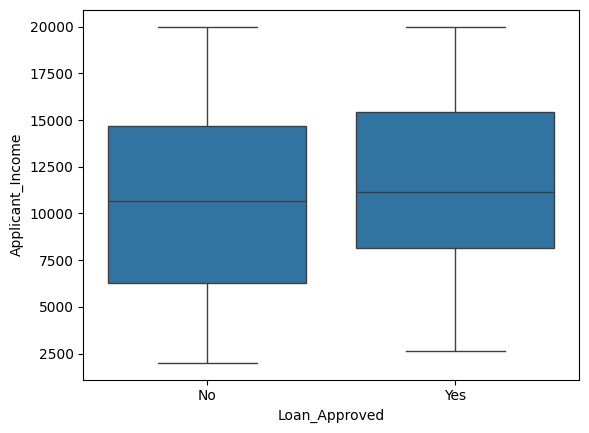

In [31]:
# outliner-box plots
sns.boxplot(
    data=loan_df,
    x="Loan_Approved",
    y="Applicant_Income"
    
)

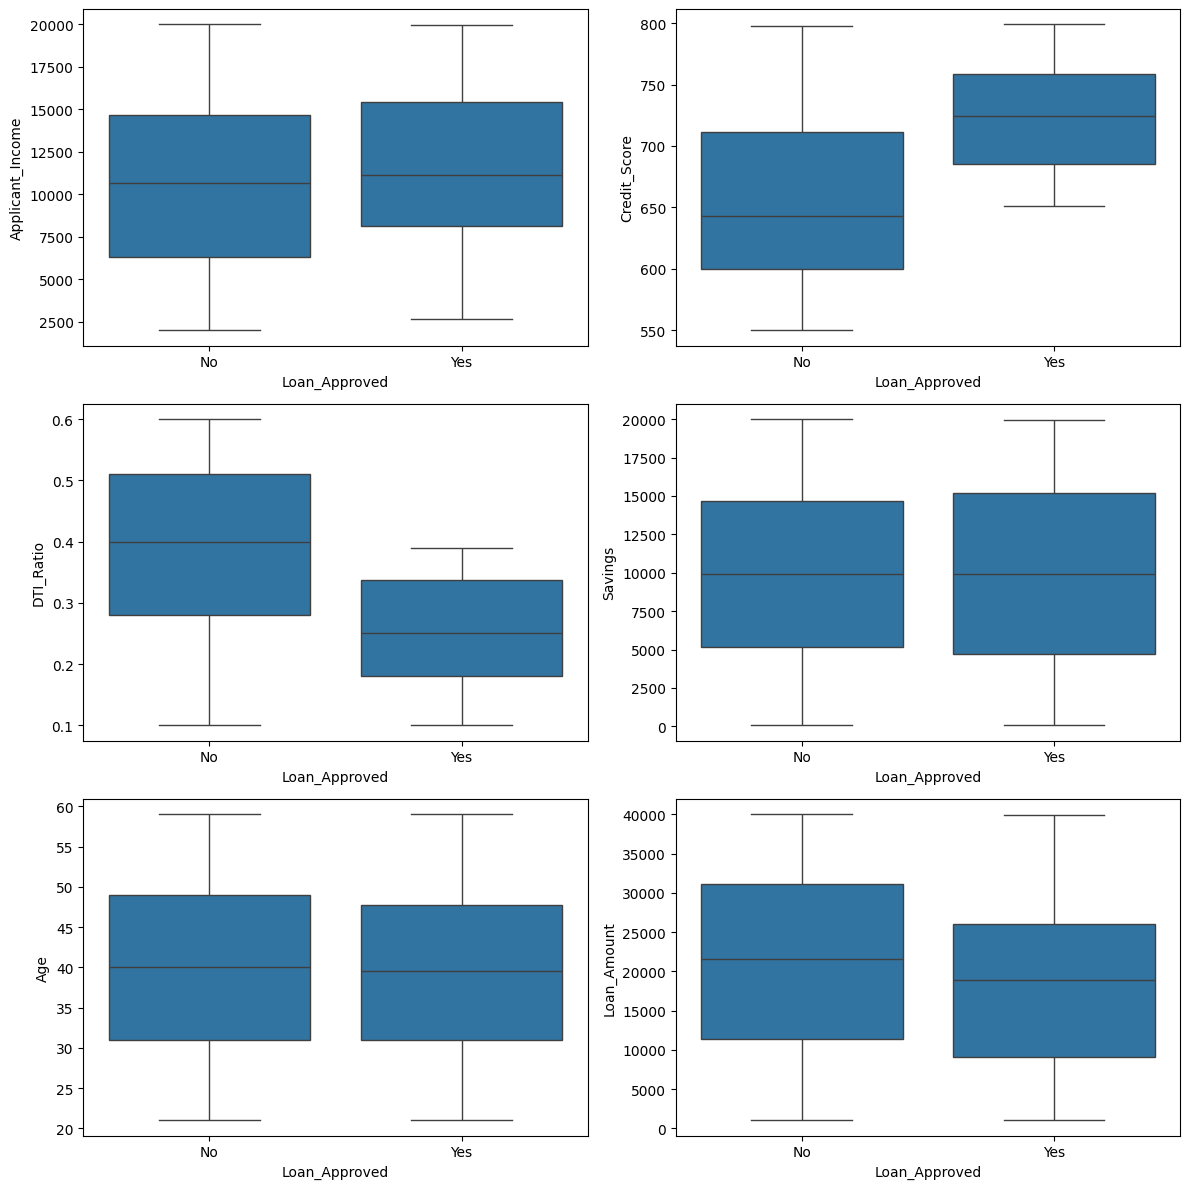

In [32]:
fig, axes = plt.subplots(3, 2, figsize=(12,12))

sns.boxplot(ax=axes[0,0],data=loan_df,
            x="Loan_Approved",
            y="Applicant_Income")
sns.boxplot(ax=axes[0,1],data=loan_df,
            x="Loan_Approved",
            y="Credit_Score")
sns.boxplot(ax=axes[1,0],data=loan_df,
            x="Loan_Approved",
            y="DTI_Ratio")
sns.boxplot(ax=axes[1,1],data=loan_df,
            x="Loan_Approved",
            y="Savings")
sns.boxplot(ax=axes[2,0],data=loan_df,
            x="Loan_Approved",
            y="Age")
sns.boxplot(ax=axes[2,1],data=loan_df,
            x="Loan_Approved",
            y="Loan_Amount")
plt.tight_layout()

<Axes: xlabel='Credit_Score', ylabel='Count'>

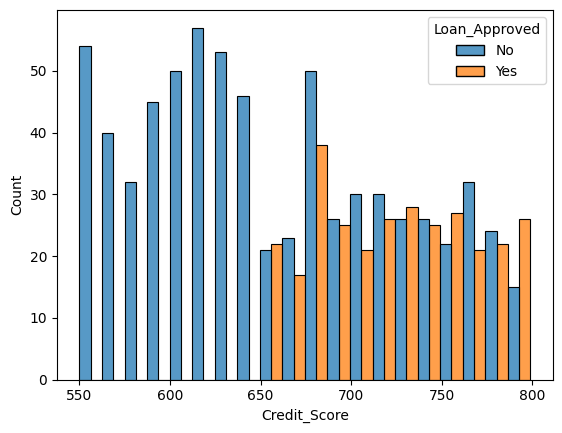

In [33]:
# credit score with Loan_Approved

sns.histplot(
    data=loan_df,
    x="Credit_Score",
    hue="Loan_Approved",
    bins=20,
    multiple="dodge"
)

<Axes: xlabel='Applicant_Income', ylabel='Count'>

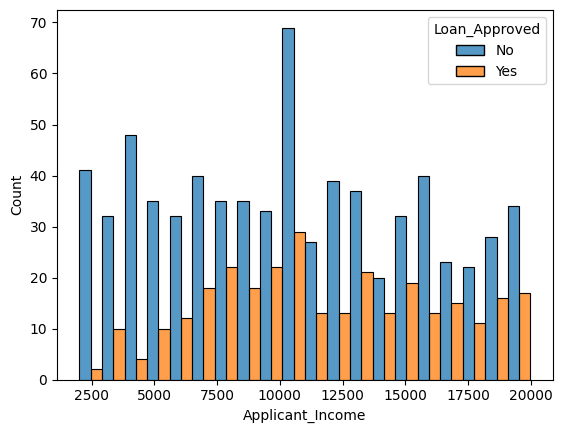

In [34]:
# credit score with Applicant_Income

sns.histplot(
    data=loan_df,
    x="Applicant_Income",
    hue="Loan_Approved",
    bins=20,
    multiple="dodge"
)

In [35]:
# remove applicant id:-Applicant_ID is an identifier, not a feature, so it was excluded to avoid misleading the model.”,“Bank gives ID so it is not needed”
loan_df=loan_df.drop("Applicant_ID",axis=1)

In [36]:
loan_df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


In [37]:
loan_df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


In [38]:
loan_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_Income    1000 non-null   float64
 1   Coapplicant_Income  1000 non-null   float64
 2   Employment_Status   1000 non-null   object 
 3   Age                 1000 non-null   float64
 4   Marital_Status      1000 non-null   object 
 5   Dependents          1000 non-null   float64
 6   Credit_Score        1000 non-null   float64
 7   Existing_Loans      1000 non-null   float64
 8   DTI_Ratio           1000 non-null   float64
 9   Savings             1000 non-null   float64
 10  Collateral_Value    1000 non-null   float64
 11  Loan_Amount         1000 non-null   float64
 12  Loan_Term           1000 non-null   float64
 13  Loan_Purpose        1000 non-null   object 
 14  Property_Area       1000 non-null   object 
 15  Education_Level     1000 non-null   object 
 16  Gender 

In [39]:
loan_df.columns

Index(['Applicant_Income', 'Coapplicant_Income', 'Employment_Status', 'Age',
       'Marital_Status', 'Dependents', 'Credit_Score', 'Existing_Loans',
       'DTI_Ratio', 'Savings', 'Collateral_Value', 'Loan_Amount', 'Loan_Term',
       'Loan_Purpose', 'Property_Area', 'Education_Level', 'Gender',
       'Employer_Category', 'Loan_Approved'],
      dtype='object')

In [40]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
#LabelEncoder-in one columns val replace with f,m to 0,1 (ordinal-order is there on thst time we use this one )
# OneHotEncoder-in here each category create the new columns /according to category create a new cloumns (nominal-on order here)

In [41]:
#LabelEncoder-in one columns val replace with f,m to 0,1 (ordinal-order is there on thst time we use this one )
le=LabelEncoder()
loan_df["Education_Level"]=le.fit_transform(loan_df["Education_Level"])
loan_df["Loan_Approved"]=le.fit_transform(loan_df["Loan_Approved"])

cols=["Employment_Status","Marital_Status","Loan_Purpose","Property_Area","Gender","Employer_Category"]

In [42]:
loan_df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,1,Female,Private,0
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,0,Male,Private,0
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,0,Female,Government,1
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,0,Female,Government,0
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,0,Male,Private,1


In [43]:
# OneHotEncoder-in here each category create the new columns /according to category create a new cloumns (nominal-on order here)

cols=["Employment_Status","Marital_Status","Loan_Purpose","Property_Area","Gender","Employer_Category"]

ohe=OneHotEncoder(drop="first",sparse_output=False,handle_unknown="ignore")# parameteres are drop,handle_unknown,sparse_output

encoded=ohe.fit_transform(loan_df[cols])

#2d array converting in to datafrom  
encoded_df=pd.DataFrame(encoded,columns=ohe.get_feature_names_out(cols),index=loan_df.index)
# append the data with origion data 
loan_df=pd.concat([loan_df.drop(columns=cols),encoded_df],axis=1)

In [44]:
encoded_df.head()

,Employment_Status_Salaried,Employment_Status_Self-employed,Employment_Status_Unemployed,Marital_Status_Single,Loan_Purpose_Car,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [45]:
encoded

array([[1., 0., 0., ..., 0., 1., 0.],
       [1., 0., 0., ..., 0., 1., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 1., ..., 0., 1., 0.],
       [1., 0., 0., ..., 0., 1., 0.]], shape=(1000, 15))

In [46]:
loan_df.head()
loan_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_Income                 1000 non-null   float64
 1   Coapplicant_Income               1000 non-null   float64
 2   Age                              1000 non-null   float64
 3   Dependents                       1000 non-null   float64
 4   Credit_Score                     1000 non-null   float64
 5   Existing_Loans                   1000 non-null   float64
 6   DTI_Ratio                        1000 non-null   float64
 7   Savings                          1000 non-null   float64
 8   Collateral_Value                 1000 non-null   float64
 9   Loan_Amount                      1000 non-null   float64
 10  Loan_Term                        1000 non-null   float64
 11  Education_Level                  1000 non-null   int64  
 12  Loan_Approved        

In [47]:
# correlation heatmap

<Axes: >

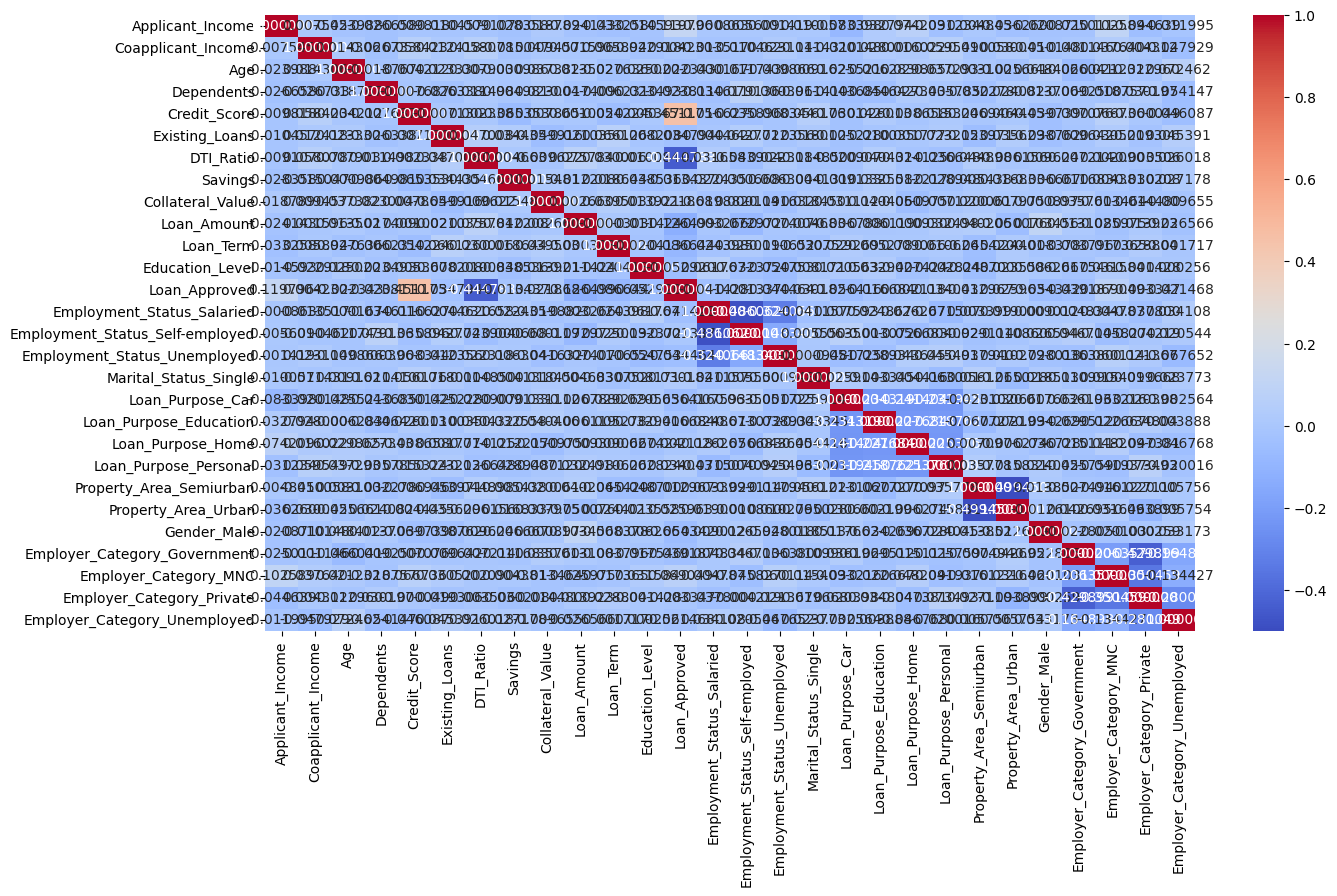

In [48]:
nums_cols=loan_df.select_dtypes(include="number")
corr_matrix = nums_cols.corr()

#heatmap:-benefits using this is the 1. i sthe quick insight get 2. detect multi collinearity mean feature of correlation remove3.data exploration 4. pre processing  
plt.figure(figsize=(15,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt="2f",
    cmap="coolwarm"
    
)

In [49]:
nums_cols.corr()["Loan_Approved"].sort_values(ascending=False)

Loan_Approved                      1.000000
Credit_Score                       0.451175
Applicant_Income                   0.119796
Employer_Category_MNC              0.069049
Loan_Purpose_Personal              0.034043
Marital_Status_Single              0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.021868
Coapplicant_Income                 0.004230
Loan_Purpose_Home                  0.002118
Employment_Status_Self-employed   -0.001337
Employer_Category_Private         -0.003347
Property_Area_Semiurban           -0.012967
Savings                           -0.013437
Loan_Purpose_Education            -0.016684
Employer_Category_Unemployed      -0.021468
Age                               -0.022343
Dependents                        -0.023811
Existing_Loans                    -0.034794
Employer_Category_Government      -0.039187
Employment_Status_Salaried        -0.041428
Employment_Status_Unemployed      -0.044464
Education_Level                 

## train_test_split the data 

In [50]:
X=loan_df.drop("Loan_Approved",axis=1)
y=loan_df["Loan_Approved"]

In [51]:
X.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [52]:
y.head()

0    0
1    0
2    1
3    0
4    1
Name: Loan_Approved, dtype: int64

In [53]:
X_train,X_test ,y_train,y_test=train_test_split(X,y,test_size=0.2, random_state=42)

In [54]:
X_test.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
521,13023.0,6675.0,53.000000,3.0,628.0,3.0,0.347263,10051.000000,26309.0,22947.000000,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
737,15917.0,6787.0,42.000000,0.0,588.0,4.0,0.410000,922.000000,13476.0,20522.825263,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
740,7560.0,3530.0,52.000000,3.0,606.0,0.0,0.580000,9940.452632,21795.0,5876.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
660,19022.0,574.0,59.000000,0.0,725.0,4.0,0.410000,1463.000000,44498.0,8433.000000,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
411,4967.0,5797.0,39.971579,3.0,697.0,4.0,0.580000,1095.000000,3017.0,33926.000000,...,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0


In [55]:
X_train.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
29,5890.000000,8041.0,31.000000,0.0,603.000000,0.000000,0.11,11906.0,8150.000000,29287.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
535,4779.000000,529.0,50.000000,0.0,614.000000,0.000000,0.21,5369.0,5430.000000,14786.000000,...,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
695,10852.571579,8927.0,36.000000,0.0,584.000000,4.000000,0.22,3186.0,24802.792632,20522.825263,...,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
557,2384.000000,2113.0,39.971579,1.0,726.000000,4.000000,0.34,11882.0,48542.000000,13312.000000,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
836,5228.000000,5249.0,42.000000,1.0,676.033684,1.950526,0.18,17669.0,24802.792632,13906.000000,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [56]:
# feature scaling:- is important for the Logistic Regression ,KNN ✅ SVM ✅ Gradient Descent–based models ✅
from sklearn.preprocessing import StandardScaler # import from sklearn 

# create a scalled
scaler=StandardScaler()

# Fit the scaler on training data and transform it
X_train_scaled =scaler.fit_transform(X_train)

# Transform the test data using the same scaler (no fitting!)
X_test_scaled=scaler.transform(X_test)

In [57]:
X_train_scaled

array([[-1.01234556e+00,  1.02716377e+00, -8.22511453e-01, ...,
        -4.13887756e-01, -8.59726954e-01, -3.07231582e-01],
       [-1.23639141e+00, -1.59187898e+00,  9.15886794e-01, ...,
        -4.13887756e-01, -8.59726954e-01, -3.07231582e-01],
       [-1.15862490e-02,  1.33606578e+00, -3.65038230e-01, ...,
        -4.13887756e-01,  1.16316000e+00, -3.07231582e-01],
       ...,
       [-2.27277589e-01,  3.50089621e-01, -8.22511453e-01, ...,
        -4.13887756e-01,  1.16316000e+00, -3.07231582e-01],
       [ 1.12970221e+00, -4.64700438e-01,  1.19037073e+00, ...,
        -4.13887756e-01, -8.59726954e-01, -3.07231582e-01],
       [-1.75526629e+00,  1.43417276e-02,  9.40348249e-04, ...,
         2.41611400e+00, -8.59726954e-01, -3.07231582e-01]],
      shape=(800, 27))

In [58]:
X_test_scaled

array([[ 0.42610546,  0.55091079,  1.19037073, ..., -0.41388776,
         1.16316   , -0.30723158],
       [ 1.00971366,  0.58995935,  0.18392964, ..., -0.41388776,
         1.16316   , -0.30723158],
       [-0.67557096, -0.54558674,  1.09887608, ..., -0.41388776,
         1.16316   , -0.30723158],
       ...,
       [-0.67980585, -0.10106072,  1.28186537, ..., -0.41388776,
         1.16316   , -0.30723158],
       [-0.37650705, -0.97825874, -0.54802752, ..., -0.41388776,
        -0.85972695, -0.30723158],
       [-0.73647272, -1.24497436,  0.73289751, ..., -0.41388776,
         1.16316   , -0.30723158]], shape=(200, 27))

In [59]:
## train and evaluate models 

In [60]:
# logistic regression

In [61]:
# import LogisticRegression form sklearn website

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score,recall_score,confusion_matrix,accuracy_score,f1_score
# create the model
log_model=LogisticRegression()
# fit LogisticRegression
log_model.fit(X_train_scaled,y_train)
# # now prediction 
# y_pred=log_model.predict(X_test_scaled)

# evaluation:-
# Model Evaluation:
# For this problem, precision and recall are more important than accuracy.
# In a loan approval system, accuracy alone can be misleading because the
# dataset may be imbalanced.

# We focus on:
# - Precision: How many predicted approved loans are actually approved
# - Recall: How many truly eligible applicants are correctly approved

# This aligns better with the problem statement than using accuracy alone.
# F1-score is also important because it provides a balance between
# precision and recall, making it a better overall evaluation metric
# for this model than accuracy.
# print("logistic regression model")
# print("precision:",precision_score(y_test,y_pred))
# print("recall:",recall_score(y_test,y_pred))
# print("confusion:",confusion_matrix(y_test,y_pred))
# print("f1:",f1_score(y_test,y_pred))
# print("accuracy:",accuracy_score(y_test,y_pred))




,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [62]:
# now prediction 
y_pred=log_model.predict(X_test_scaled)


In [63]:
# evaluation:-
from sklearn.metrics import precision_score,recall_score,confusion_matrix,accuracy_score,f1_score
print("logistic regression model")
print("precision:",precision_score(y_test,y_pred))
print("recall:",recall_score(y_test,y_pred))
print("confusion:",confusion_matrix(y_test,y_pred))
print("f1:",f1_score(y_test,y_pred))
print("accuracy:",accuracy_score(y_test,y_pred))



logistic regression model
precision: 0.7833333333333333
recall: 0.7704918032786885
confusion: [[126  13]
 [ 14  47]]
f1: 0.7768595041322314
accuracy: 0.865


In [64]:
# import KNeighborsClassifier form sklearn website
from sklearn.neighbors import KNeighborsClassifier
# create the model
knn_model=KNeighborsClassifier(n_neighbors=5)
# fit LogisticRegression
knn_model.fit(X_train_scaled,y_train)
# # now prediction 
# y_pred=knn_model.predict(X_test_scaled)




,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [65]:
# now prediction 
y_pred=knn_model.predict(X_test_scaled)


In [66]:
# evaluation:-
from sklearn.metrics import precision_score,recall_score,confusion_matrix,accuracy_score,f1_score

print("knn model")
print("precision:",precision_score(y_test,y_pred))
print("recall:",recall_score(y_test,y_pred))
print("confusion:",confusion_matrix(y_test,y_pred))
print("f1:",f1_score(y_test,y_pred))
print("accuracy:",accuracy_score(y_test,y_pred))


knn model
precision: 0.6274509803921569
recall: 0.5245901639344263
confusion: [[120  19]
 [ 29  32]]
f1: 0.5714285714285714
accuracy: 0.76


In [67]:
# import naive_bayes form sklearn website
from sklearn.naive_bayes import GaussianNB
# create the model
nb_model=GaussianNB()
# fit LogisticRegression
nb_model.fit(X_train_scaled,y_train)
# # now prediction 

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [68]:
# now prediction 
y_pred=nb_model.predict(X_test_scaled)


In [69]:

# evaluation:-
from sklearn.metrics import precision_score,recall_score,confusion_matrix,accuracy_score,f1_score

print("nb  model")
print("precision:",precision_score(y_test,y_pred))
print("recall:",recall_score(y_test,y_pred))
print("confusion:",confusion_matrix(y_test,y_pred))
print("f1:",f1_score(y_test,y_pred))
print("accuracy:",accuracy_score(y_test,y_pred))


nb  model
precision: 0.8035714285714286
recall: 0.7377049180327869
confusion: [[128  11]
 [ 16  45]]
f1: 0.7692307692307693
accuracy: 0.865


In [70]:
# best  is nb for the loan approved here this is best model 

In [71]:
# feature engineering 

In [72]:
# add or transform features
loan_df["DTI_Ratio_sq"]=loan_df["DTI_Ratio"]**2
loan_df["Credit_Score_sq"]=loan_df["Credit_Score"]**2
# skewed some data 
loan_df["Applicant_Income_log"]=np.log1p(loan_df["Applicant_Income"])
# calu x,y
X=loan_df.drop(columns=["Loan_Approved","Credit_Score","DTI_Ratio"])
y=loan_df["Loan_Approved"]
# train test split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

# feature scaling
# create a scalled
scaler=StandardScaler()

# Fit the scaler on training data and transform it
X_train_scaled =scaler.fit_transform(X_train)

# Transform the test data using the same scaler (no fitting!)
X_test_scaled=scaler.transform(X_test)


In [73]:
X_train.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Existing_Loans,Savings,Collateral_Value,Loan_Amount,Loan_Term,Education_Level,...,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,DTI_Ratio_sq,Credit_Score_sq,Applicant_Income_log
29,5890.000000,8041.0,31.000000,0.0,0.000000,11906.0,8150.000000,29287.000000,12.0,1,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0121,363609.000000,8.681181
535,4779.000000,529.0,50.000000,0.0,0.000000,5369.0,5430.000000,14786.000000,72.0,1,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0441,376996.000000,8.472196
695,10852.571579,8927.0,36.000000,0.0,4.000000,3186.0,24802.792632,20522.825263,48.0,1,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0484,341056.000000,9.292249
557,2384.000000,2113.0,39.971579,1.0,4.000000,11882.0,48542.000000,13312.000000,24.0,0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.1156,527076.000000,7.776954
836,5228.000000,5249.0,42.000000,1.0,1.950526,17669.0,24802.792632,13906.000000,84.0,0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0324,457021.542187,8.561975


In [74]:
# logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score,recall_score,confusion_matrix,accuracy_score,f1_score
# create the model
log_model=LogisticRegression()
# fit LogisticRegression
log_model.fit(X_train_scaled,y_train)
# now prediction 
y_pred=log_model.predict(X_test_scaled)
# evaluation:-
print("logistic regression model")
print("precision:",precision_score(y_test,y_pred))
print("recall:",recall_score(y_test,y_pred))
print("confusion:",confusion_matrix(y_test,y_pred))
print("f1:",f1_score(y_test,y_pred))
print("accuracy:",accuracy_score(y_test,y_pred))


logistic regression model
precision: 0.7846153846153846
recall: 0.8360655737704918
confusion: [[125  14]
 [ 10  51]]
f1: 0.8095238095238095
accuracy: 0.88


In [75]:
# import KNeighborsClassifier form sklearn website
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import precision_score,recall_score,confusion_matrix,accuracy_score,f1_score
# create the model
knn_model=KNeighborsClassifier(n_neighbors=5)
# fit LogisticRegression
knn_model.fit(X_train_scaled,y_train)
# now prediction 
y_pred=knn_model.predict(X_test_scaled)
# evaluation:-
print("knn model")
print("precision:",precision_score(y_test,y_pred))
print("recall:",recall_score(y_test,y_pred))
print("confusion:",confusion_matrix(y_test,y_pred))
print("f1:",f1_score(y_test,y_pred))
print("accuracy:",accuracy_score(y_test,y_pred))



knn model
precision: 0.6730769230769231
recall: 0.5737704918032787
confusion: [[122  17]
 [ 26  35]]
f1: 0.6194690265486725
accuracy: 0.785


In [76]:
# import naive_bayes form sklearn website
from sklearn.naive_bayes import GaussianNB
# create the model
nb_model=GaussianNB()
# fit LogisticRegression
nb_model.fit(X_train_scaled,y_train)
# now prediction 
y_pred=nb_model.predict(X_test_scaled)
# evaluation:-
from sklearn.metrics import precision_score,recall_score,confusion_matrix,accuracy_score,f1_score

print("nb  model")
print("precision:",precision_score(y_test,y_pred))
print("recall:",recall_score(y_test,y_pred))
print("confusion:",confusion_matrix(y_test,y_pred))
print("f1:",f1_score(y_test,y_pred))
print("accuracy:",accuracy_score(y_test,y_pred))


nb  model
precision: 0.8113207547169812
recall: 0.7049180327868853
confusion: [[129  10]
 [ 18  43]]
f1: 0.7543859649122807
accuracy: 0.86
